In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn 
import torch.optim as optim
device = torch.device('cuda')

In [158]:
df = pd.read_csv('student_placement_synthetic.csv')
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [159]:
try:
  df.drop(columns=['salary_package_lpa'],inplace=True)
except:
  pass

In [160]:
df['branch'] = df['branch'].astype('category')
df['college_tier'] = df['college_tier'].astype('category')

In [161]:
df['tech_skill_score'] = (
    df['coding_skills'] +
    df['dsa_score'] +
    df['ml_knowledge'] +
    df['system_design']
)

In [162]:
df['profile_strength'] = (
    df['internships'] +
    df['projects_count'] +
    df['certifications'] +
    df['hackathons'] +
    df['open_source_contributions']
)

In [163]:
df['soft_skill_score'] = (
    df['communication_skills'] +
    df['aptitude_score']
)

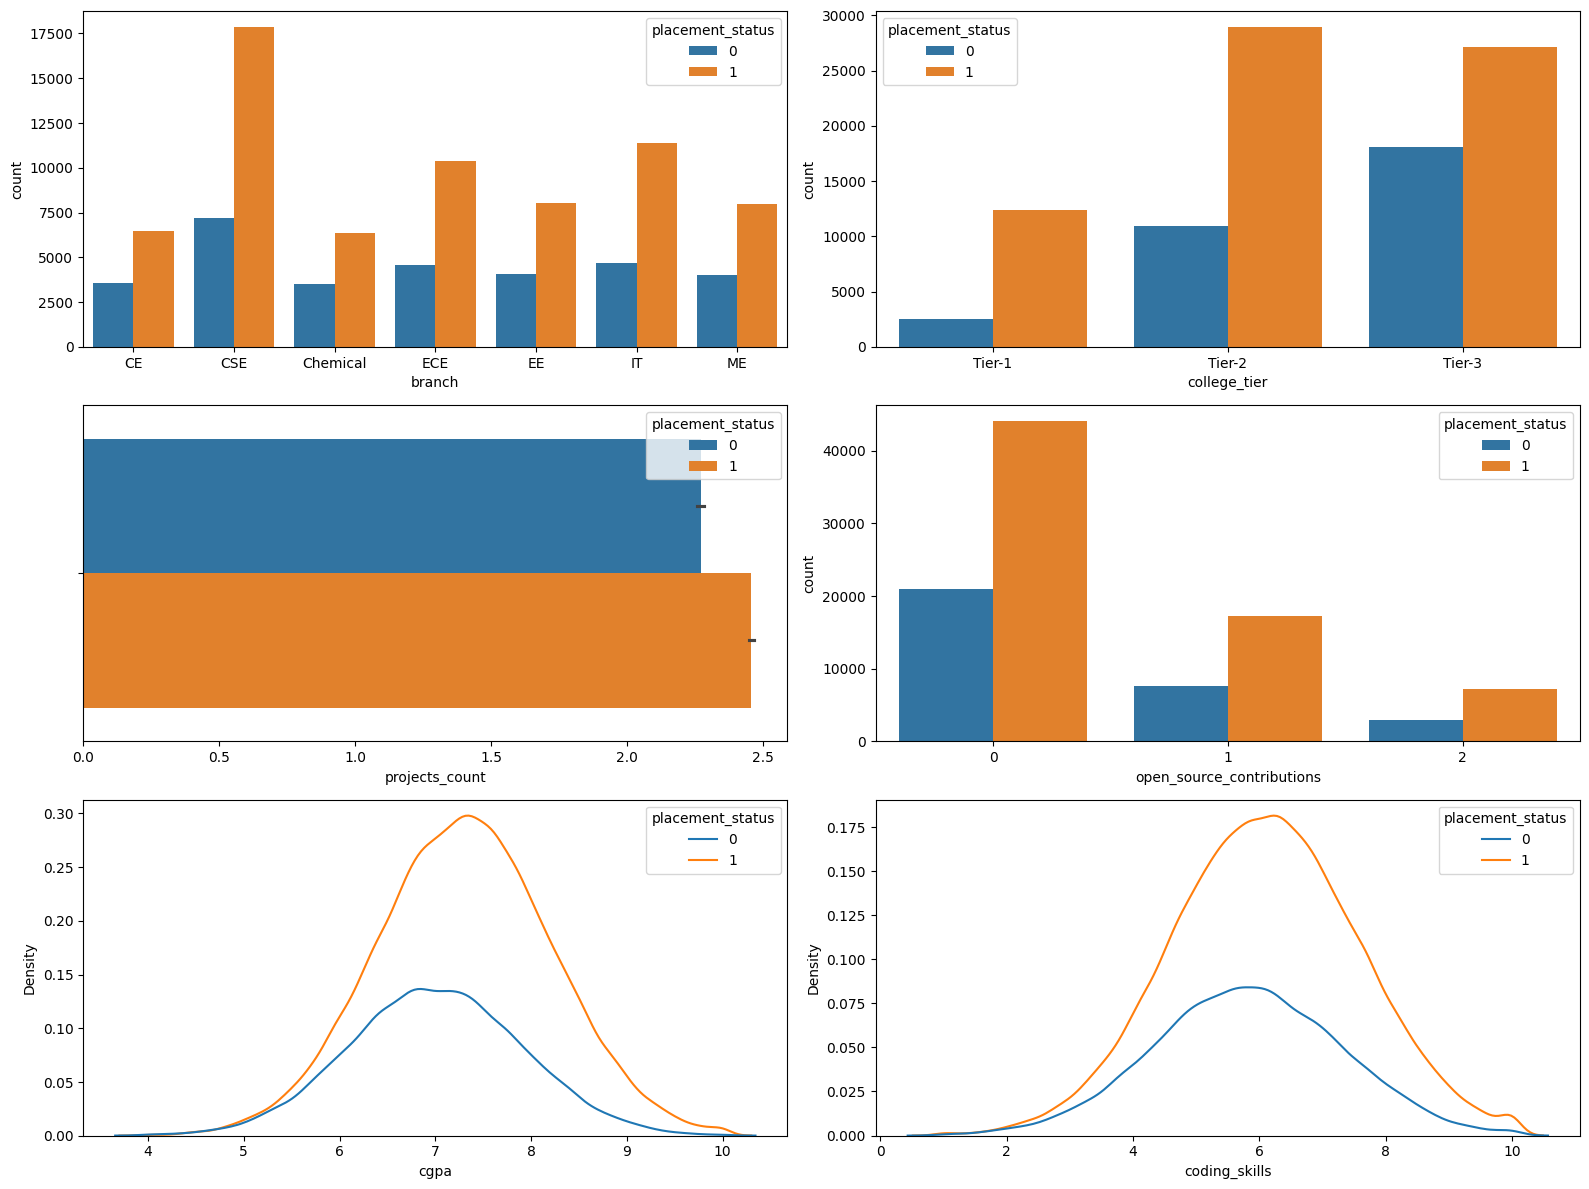

In [164]:
fig,axes = plt.subplots(3,2,figsize=(16,12))
sns.countplot(data=df,x='branch',ax=axes[0,0],hue='placement_status')
sns.countplot(data=df,x='college_tier',ax=axes[0,1],hue='placement_status')
sns.barplot(data=df,x='projects_count',ax=axes[1,0],hue='placement_status')
sns.countplot(data=df,x='open_source_contributions',ax=axes[1,1],hue='placement_status')
sns.kdeplot(data=df,x='cgpa',ax=axes[2,0],hue='placement_status')
sns.kdeplot(data=df,x='coding_skills',ax=axes[2,1],hue='placement_status')
plt.tight_layout()
plt.show()

In [165]:
df = pd.get_dummies(df, columns=['branch','college_tier'], drop_first=True)

In [166]:
num_cols = df.select_dtypes(['int','float']).columns

In [167]:
df[num_cols].corr()['placement_status'].sort_values(ascending=False)

placement_status             1.000000
cgpa                         0.148932
profile_strength             0.129538
internships                  0.099967
coding_skills                0.087657
dsa_score                    0.086594
tech_skill_score             0.081257
projects_count               0.069900
certifications               0.055636
soft_skill_score             0.051091
communication_skills         0.051034
aptitude_score               0.045146
hackathons                   0.033315
open_source_contributions    0.022723
ml_knowledge                 0.002097
system_design               -0.001583
extracurriculars            -0.004807
backlogs                    -0.058815
Name: placement_status, dtype: float64

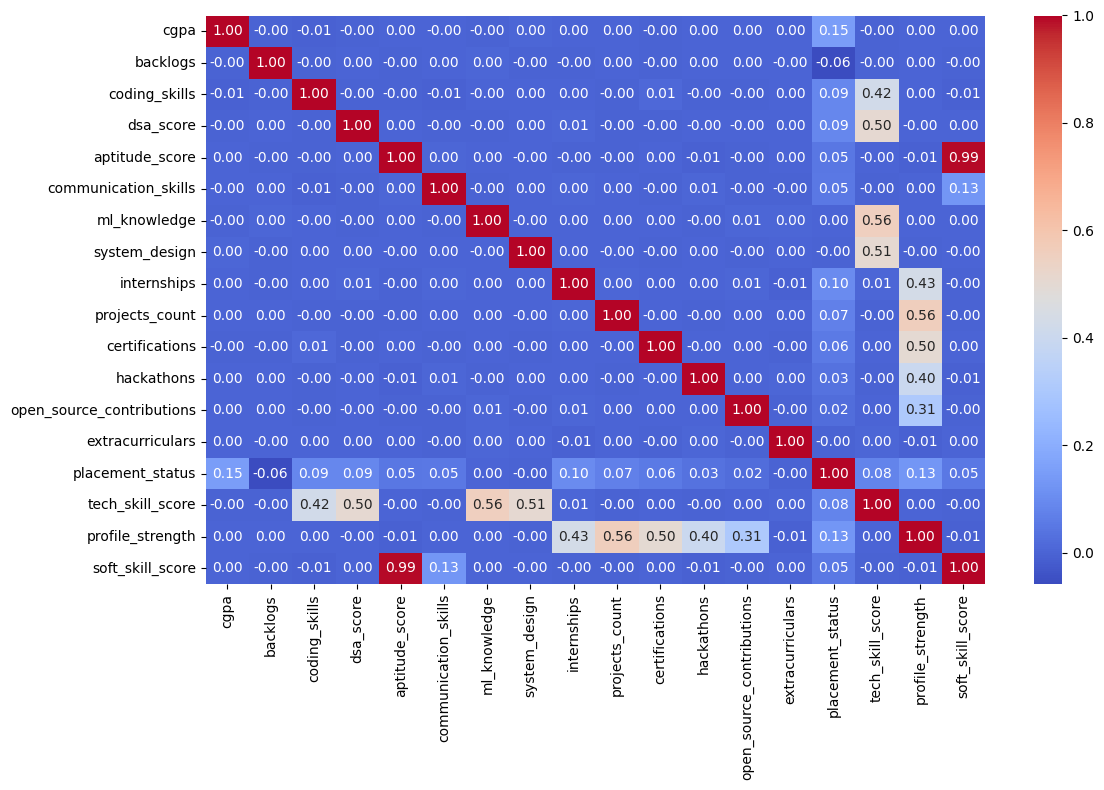

In [168]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),fmt='.2f',cmap='coolwarm',annot=True)
plt.tight_layout()
plt.show()

In [169]:
X = df.drop(columns=['placement_status'])
y = df['placement_status']

In [170]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [171]:
num_cols = X.select_dtypes(['int','float','bool']).columns

In [172]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)